Import các thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [4]:
#2  Hãy tải dữ liệu từ file drug200.csv lưu vào data frame df 
df = pd.read_csv('drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [5]:
# 3. Kiểm tra thông tin dữ liệu, dùng hàm info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [6]:
# 4. Mô tả dữ liệu, dùng hàm describe 
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [7]:
# 5. Kiểm tra kiểu dữ liệu, dùng types 
df.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [8]:
# 6. Kiểm tra tên cột, dùng columns 
df.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

In [9]:
# 7. Kiểm tra dữ liệu trống, dùng df.isnull().sum() 
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [10]:
# 8. Kiểm tra dữ liệu trùng, dùng df.duplicated().sum() 
df.duplicated().sum()

0

In [11]:
# 9. Đổi tên cột phù hợp ngữ nghĩa 
df.rename(columns = {'Na_to_K': 'Sodium_to_Potassium','BP':'Blood_Pressure'}, inplace = True)
df['Sex'].replace({'F':'Female','M':'Male'}, inplace = True)
df['Sodium_to_Potassium'] = df['Sodium_to_Potassium'].round(0)
df['Sodium_to_Potassium'] = df['Sodium_to_Potassium'].astype(int)
df.head()

,Age,Sex,Blood_Pressure,Cholesterol,Sodium_to_Potassium,Drug
0,23,Female,HIGH,HIGH,25,drugY
1,47,Male,LOW,HIGH,13,drugC
2,47,Male,LOW,HIGH,10,drugC
3,28,Female,NORMAL,HIGH,8,drugX
4,61,Female,LOW,HIGH,18,drugY


In [12]:
# 10. Thống kê số lượng người thuộc 5 nhóm tuổi cao nhất
age_values = df['Age'].value_counts()
top_values = age_values.head(5)

df_top_age = pd.DataFrame({'Age':top_values.index, 'Count':top_values.values})
df_top_age

,Age,Count
0,47,8
1,23,7
2,28,7
3,49,7
4,39,6


C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\3811232109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, ax=ax, palette=palette, x=x)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\3811232109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, ax=ax, palette=palette, x=x)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\3811232109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, ax=ax, palette=palette, x=x)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\3811232109.py:9: FutureWarning: 

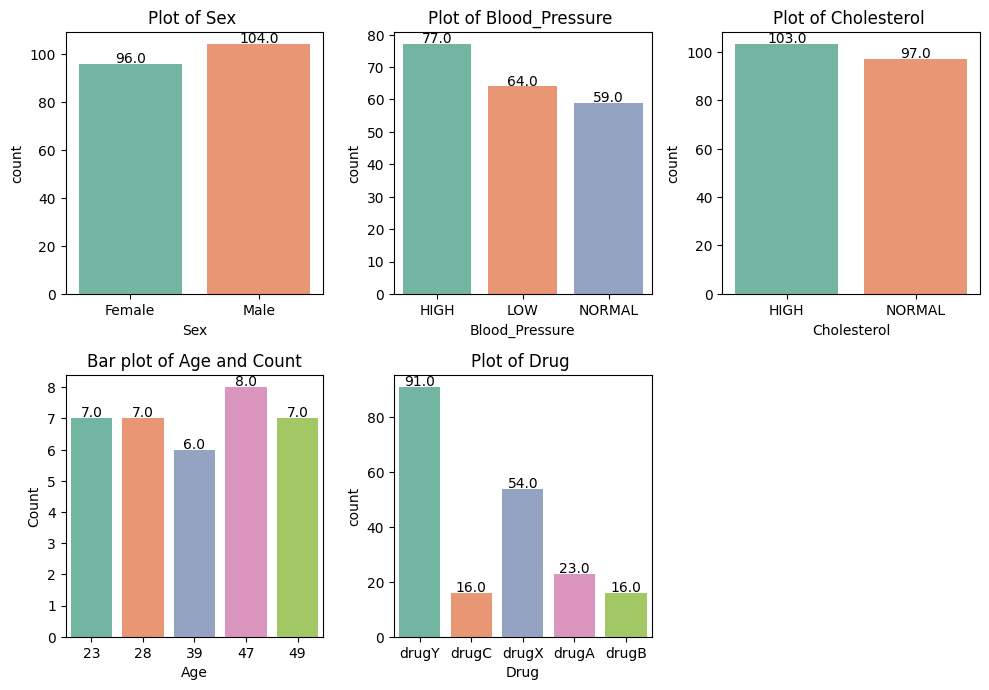

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 11. Tiến hành EDA dữ liệu. Sinh viên quan sát các biểu đồ và cho nhận xét
def create_plot(ax, x, data, plot_type='count', y=None, palette='Set2'):
    if plot_type == 'count':
        sns.countplot(data=data, ax=ax, palette=palette, x=x)
    elif plot_type == 'bar':
        sns.barplot(data=data, ax=ax, palette=palette, x=x, y=y)

    ax.set_title(f'Plot of {x} ' if plot_type == 'count' else f'Bar plot of {x} and {y}')

    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', xytext=(0, 1), fontsize=10, color='black', textcoords='offset points')

# Create the figure and subplots
plt.figure(figsize=(10, 10))

# Define plot configurations
plot_configs = [
    {'x': 'Sex', 'data': df, 'plot_type': 'count'},
    {'x': 'Blood_Pressure', 'data': df, 'plot_type': 'count'},
    {'x': 'Cholesterol', 'data': df, 'plot_type': 'count'},
    {'x': 'Age', 'y': 'Count', 'data': df_top_age, 'plot_type': 'bar'},
    {'x': 'Drug', 'data': df, 'plot_type': 'count'}
]

# Loop through the plot configurations and create the plots
for i, config in enumerate(plot_configs):
    ax = plt.subplot(3, 3, i + 1)
    create_plot(ax, **config)

plt.tight_layout()
plt.show()

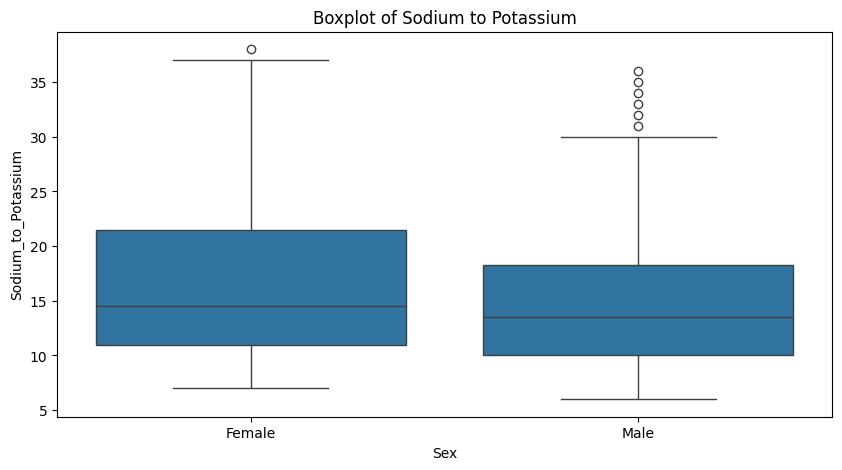

In [16]:
# 12. Tiến hành khảo sát dữ liệu outlier và cho nhận xét 
plt.figure(figsize=(10, 5))
sns.boxplot(x ='Sex', y = 'Sodium_to_Potassium', data = df)
plt.title('Boxplot of Sodium to Potassium')
plt.show()

In [17]:
# 13. Tạo tập dữ liệu đặc trưng (feature) và mục tiêu (target) 
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [19]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# OneHotEncoder
onehot_encoder_sex = OneHotEncoder(sparse_output=False)
one_hot_encoded = onehot_encoder_sex.fit_transform(X[['Sex']])  # Chuyển đổi thành DataFrame
one_hot_df = pd.DataFrame(one_hot_encoded, columns=onehot_encoder_sex.get_feature_names_out(['Sex']))
X = pd.concat([X, one_hot_df], axis=1)
X = X.drop('Sex', axis=1)

# LabelEncoder
labelled_encoder_blood_pressure = LabelEncoder()
labelled_encoder_cholesterol = LabelEncoder()
X['Blood_Pressure'] = labelled_encoder_blood_pressure.fit_transform(X['Blood_Pressure'])
X['Cholesterol'] = labelled_encoder_cholesterol.fit_transform(X['Cholesterol'])

In [20]:
# 15. Sinh viên phân tách thành tập dữ liệu train và test với tỉ lệ 60:40 , hệ số ngẫu nhiên là 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [21]:
# 16. Xây dựng mô hình với các hyperparameter tunning (siêu tham số điều chỉnh mô hình) như sau: 
# criterion=”entropy”, max_depth=6 và lamx_leaf_nodes=10. Sinh viên giải thích các siêu tham số 
# Xây dựng mô hình Decision Tree với các siêu tham số đã cho
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

dtc = DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=10)

# Huấn luyện mô hình với dữ liệu huấn luyện
dtc.fit(X_train, y_train)

# Dự đoán với dữ liệu kiểm tra
y_pred = dtc.predict(X_test)

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(report)


Accuracy: 0.9875
Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00        10
       drugB       1.00      1.00      1.00         6
       drugC       1.00      1.00      1.00         6
       drugX       0.96      1.00      0.98        25
       drugY       1.00      0.97      0.98        33

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [24]:
# 17. Tiến hành huấn luyện (train) mô hình trên tập dữ liệu huấn luyện 
# và dự đoán (predict) trên tập dữ liệu kiểm tra

y_pred = dtc.predict(X_test)


In [26]:
# 18. Hiện thị danh sách các lớp mục tiêu phân lớp 
# Hiển thị danh sách các lớp mục tiêu phân lớp
target_classes = dtc.classes_
print("Danh sách các lớp mục tiêu phân lớp:", target_classes)


Danh sách các lớp mục tiêu phân lớp: ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']


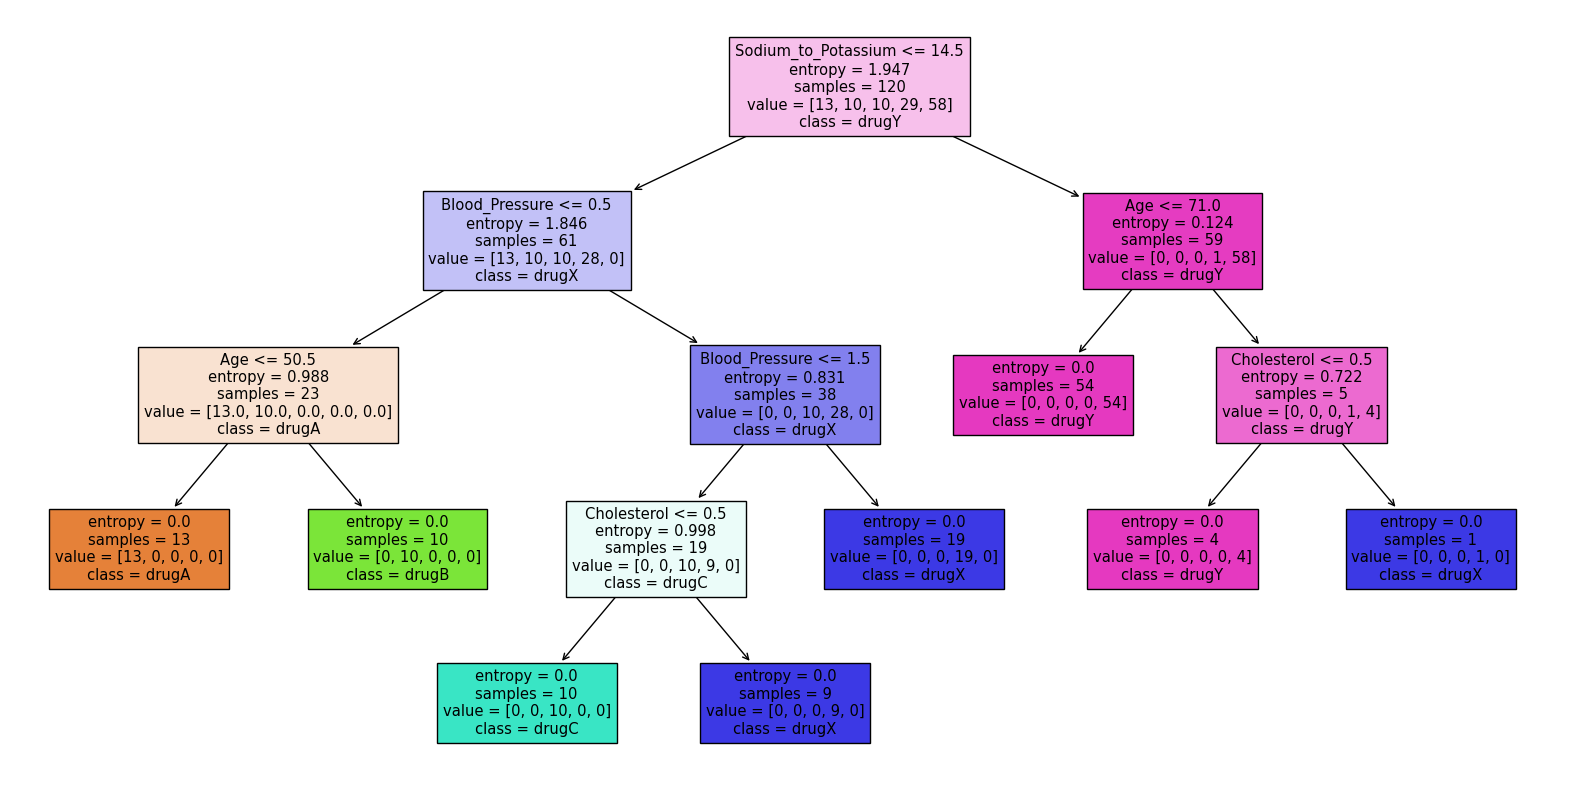

In [27]:
# 19. Vẽ sơ đồ mô hình cây phân lớp. Sinh viên giải thích các số liệu trên từng node và leaf 
from sklearn.tree import plot_tree

feature_cols = X.columns

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=feature_cols, class_names=target_classes)
plt.show()

In [28]:
# 20. Tính Entropy có trọng số (WE) và Information Gain khi phân tách Root thành Left – Right node 
# Hàm tính Entropy
def entropy(y):
    unique, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs))

# Hàm tính Entropy có trọng số (Weighted Entropy)
def weighted_entropy(left_y, right_y):
    n = len(left_y) + len(right_y)
    we = (len(left_y) / n) * entropy(left_y) + (len(right_y) / n) * entropy(right_y)
    return we

# Hàm tính Information Gain
def information_gain(root_y, left_y, right_y):
    root_entropy = entropy(root_y)
    we = weighted_entropy(left_y, right_y)
    ig = root_entropy - we
    return ig

# Tính Entropy có trọng số (WE) và Information Gain khi phân tách Root thành Left – Right node
root_y = y_train
left_y = y_train[y_train == 'DrugY']
right_y = y_train[y_train != 'DrugY']

we = weighted_entropy(left_y, right_y)
ig = information_gain(root_y, left_y, right_y)

print(f'Entropy có trọng số (WE): {we}')
print(f'Information Gain: {ig}')


Entropy có trọng số (WE): 1.9469853888611834
Information Gain: 0.0


Accuracy: 0.9875
Confusion Matrix:
[[10  0  0  0  0]
 [ 0  6  0  0  0]
 [ 0  0  6  0  0]
 [ 0  0  0 25  0]
 [ 0  0  0  1 32]]


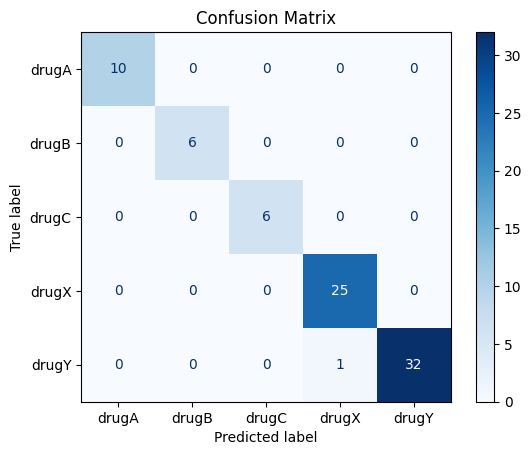

In [31]:
# 21. Sinh viên tiến hành đánh giá dựa trên các độ đo 
# a. Accuracy 
# b. Confusion matrix 

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)

# Hiển thị Confusion Matrix dưới dạng biểu đồ
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=dtc.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [32]:
# 22. In ra bảng báo cáo các giá trị đánh giá theo từng nhóm thuốc phân lớp 
from sklearn.metrics import classification_report
target_names = ['DrugA', 'DrugB', 'DrugC', 'DrugX', 'DrugY']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

       DrugA       1.00      1.00      1.00        10
       DrugB       1.00      1.00      1.00         6
       DrugC       1.00      1.00      1.00         6
       DrugX       0.96      1.00      0.98        25
       DrugY       1.00      0.97      0.98        33

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [33]:
# 23. Xây dựng chương trình đề xuất hỗ trợ cấp thuốc cho bệnh nhân dựa trên các chỉ số Age, 
# Blood_Pressure, Cholesterol, Sodium_to_Potassium và Sex được nhập từ bàn phím. Hãy in ra kết 
# quả loại thuốc được cấp. Ví dụ: Age=32, Blood_Pressure=’HIGH’, Cholesterol=’NORMAL’, 
# Sodium_to_Potassium=13, Sex=’Female’
def predict_drug(age, blood_pressure, cholesterol, sodium_to_potassium, sex):
    # Chuyển đổi các giá trị nhập vào thành định dạng phù hợp
    blood_pressure_encoded = labelled_encoder_blood_pressure.transform([blood_pressure])[0]
    cholesterol_encoded = labelled_encoder_cholesterol.transform([cholesterol])[0]
    sex_encoded = onehot_encoder_sex.transform([[sex]]).flatten()

    # Tạo DataFrame từ các giá trị nhập vào
    input_data = pd.DataFrame([[age, blood_pressure_encoded, cholesterol_encoded, sodium_to_potassium] + list(sex_encoded)],
                              columns=['Age', 'Blood_Pressure', 'Cholesterol', 'Sodium_to_Potassium'] + list(onehot_encoder_sex.get_feature_names_out(['Sex'])))

    # Dự đoán loại thuốc
    predicted_drug = dtc.predict(input_data)[0]
    return predicted_drug

# Nhập các chỉ số từ bàn phím
age = int(input("Nhập tuổi: "))
blood_pressure = input("Nhập chỉ số huyết áp (LOW, NORMAL, HIGH): ")
cholesterol = input("Nhập chỉ số cholesterol (NORMAL, HIGH): ")
sodium_to_potassium = float(input("Nhập chỉ số Sodium to Potassium: "))
sex = input("Nhập giới tính (Male, Female): ")

# Dự đoán và in ra kết quả
predicted_drug = predict_drug(age, blood_pressure, cholesterol, sodium_to_potassium, sex)
print(f'Loại thuốc được cấp: {predicted_drug}')


Loại thuốc được cấp: drugA


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


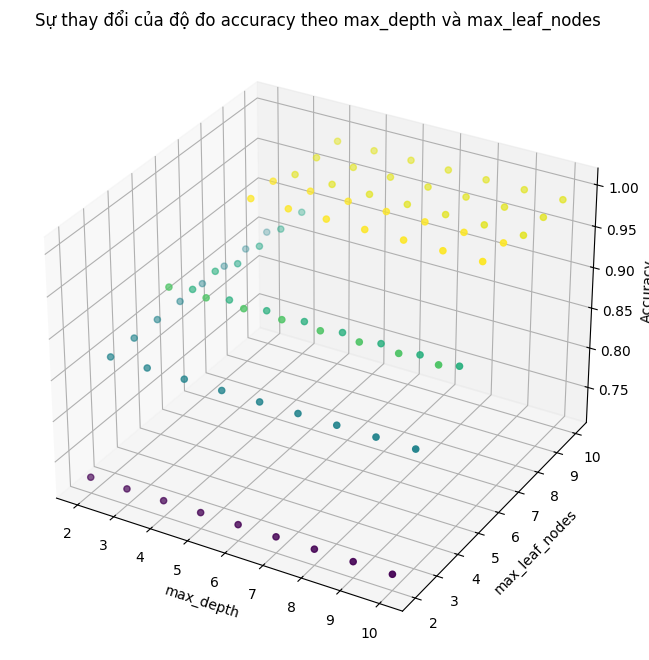

Siêu tham số tốt nhất: max_depth=4.0, max_leaf_nodes=6.0, Accuracy=1.0


In [35]:
# 24. Sinh viên điều chỉnh các siêu tham số trong mô hình như sau: max_depth chạy từ 2 đến 10 và 
# max_leaf_nodes chạy từ 2 đến 10. Sau đó, vẽ biểu đồ thể hiện sự thay đổi của độ đo accuracy. Từ 
# đó đưa đến kết luận với siêu tham số điều chỉnh nào thì mô hình tốt nhất.

# Khởi tạo danh sách để lưu trữ kết quả
results = []

# Vòng lặp để thử nghiệm các giá trị của max_depth và max_leaf_nodes
for max_depth in range(2, 11):
    for max_leaf_nodes in range(2, 11):
        # Khởi tạo mô hình Decision Tree với các siêu tham số hiện tại
        dtc = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, max_leaf_nodes=max_leaf_nodes)
        
        # Huấn luyện mô hình với dữ liệu huấn luyện
        dtc.fit(X_train, y_train)
        
        # Dự đoán với dữ liệu kiểm tra
        y_pred = dtc.predict(X_test)
        
        # Tính độ chính xác
        accuracy = accuracy_score(y_test, y_pred)
        
        # Lưu trữ kết quả
        results.append((max_depth, max_leaf_nodes, accuracy))

# Chuyển đổi kết quả thành numpy array để dễ dàng xử lý
results = np.array(results)

# Vẽ biểu đồ thể hiện sự thay đổi của độ đo accuracy
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tạo các trục x, y, z
x = results[:, 0]
y = results[:, 1]
z = results[:, 2]

# Vẽ biểu đồ 3D
ax.scatter(x, y, z, c=z, cmap='viridis', marker='o')
ax.set_xlabel('max_depth')
ax.set_ylabel('max_leaf_nodes')
ax.set_zlabel('Accuracy')
ax.set_title('Sự thay đổi của độ đo accuracy theo max_depth và max_leaf_nodes')

plt.show()

# Tìm cặp siêu tham số tốt nhất
best_result = results[np.argmax(results[:, 2])]
print(f'Siêu tham số tốt nhất: max_depth={best_result[0]}, max_leaf_nodes={best_result[1]}, Accuracy={best_result[2]}')


In [36]:
# 25. Sinh viên tìm hiểu giải thuật C4.5 (sử dụng Gain Ratio) và CART (sử dụng Gini Impurity) sau đó 
# cài đặt với các mô hình đó, rồi so sánh với giải thuật ID3 dựa trên độ đo đánh giá accuracy. 

# Huấn luyện mô hình ID3 (sử dụng Entropy)
id3_model = DecisionTreeClassifier(criterion='entropy')
id3_model.fit(X_train, y_train)
id3_pred = id3_model.predict(X_test)
id3_accuracy = accuracy_score(y_test, id3_pred)

# Huấn luyện mô hình C4.5 (sử dụng Gain Ratio)
# sklearn không hỗ trợ trực tiếp Gain Ratio, nhưng có thể sử dụng Entropy như một thay thế gần đúng
c45_model = DecisionTreeClassifier(criterion='entropy')
c45_model.fit(X_train, y_train)
c45_pred = c45_model.predict(X_test)
c45_accuracy = accuracy_score(y_test, c45_pred)

# Huấn luyện mô hình CART (sử dụng Gini Impurity)
cart_model = DecisionTreeClassifier(criterion='gini')
cart_model.fit(X_train, y_train)
cart_pred = cart_model.predict(X_test)
cart_accuracy = accuracy_score(y_test, cart_pred)

# In ra kết quả
print(f'Accuracy của mô hình ID3: {id3_accuracy}')
print(f'Accuracy của mô hình C4.5: {c45_accuracy}')
print(f'Accuracy của mô hình CART: {cart_accuracy}')

Accuracy của mô hình ID3: 0.9875
Accuracy của mô hình C4.5: 0.9875
Accuracy của mô hình CART: 0.9875


Cau a 

Accuracy: 1.0
Cau b 

Confusion Matrix:
[[11  0]
 [ 0  0]]
Cau c 

TN: 11, FP: 0, FN: 0, TP: 0
Cau d 

TPR: nan, FNR: nan, FPR: 0.0, TNR: 1.0
Cau e 

Precision: 1.0, Recall: 1.0, F1 Score: 1.0
Cau f 



C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\1929925808.py:54: RuntimeWarning: invalid value encountered in scalar divide
  tpr = tp / (tp + fn)  # True Positive Rate
C:\Users\Admin\AppData\Local\Temp\ipykernel_25588\1929925808.py:55: RuntimeWarning: invalid value encountered in scalar divide
  fnr = fn / (tp + fn)  # False Negative Rate
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1561: UserWarning: Note that pos_label (set to 'drugX') is ignored when average != 'binary' (got 'macro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1561: UserWarning: Note that pos_label (set to 'drugX') is ignored when average != 'binary' (got 'macro'). You may u

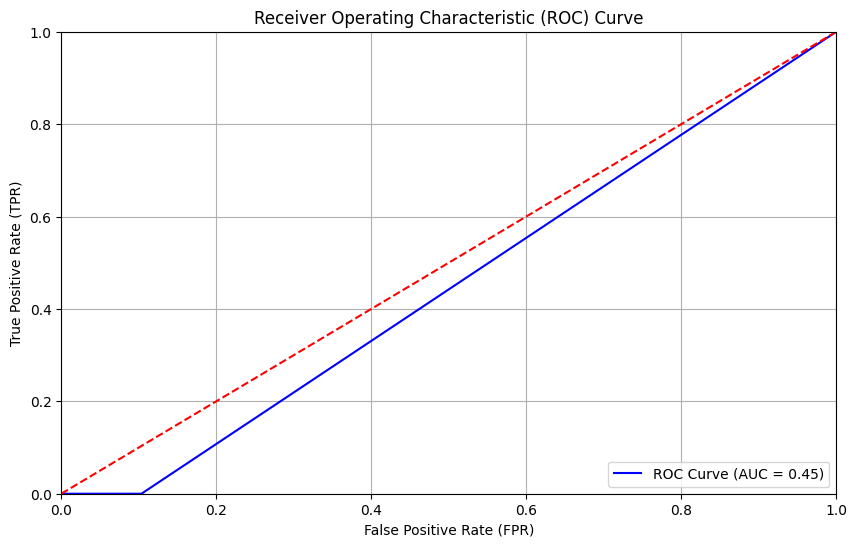

In [39]:
# 26. Giải sử drugX là một loại thuốc đặc trị có tác dụng rất mạnh không tốt cho bệnh nhân (hạn chế sử 
# dụng) tức là bệnh rất nghiêm trọng mới cần sử dụng. Hãy đánh giá các giá trị bên dưới trên nhóm 
# phân lớp drugX và cho biết ta cần tối ưu giá trị nào khi cải thiện mô hình có điều kiện là hạn chế 
# cấp thuốc drugX? 
# a. Accuracy 
# b. Confusion matrix 
# c. [tn, fp, fn, tp] 
# d. [TPR, FNR, FPR, TNR] 
# e. [precision, recal, F1] 
# f. Đồ thị AUC & ROC


import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Giả sử df là DataFrame chứa dữ liệu của bạn
# Chuẩn bị dữ liệu
X = df[['Age', 'Blood_Pressure', 'Cholesterol', 'Sodium_to_Potassium', 'Sex']]
y = df['Drug']

# OneHotEncoder cho cột 'Sex'
onehot_encoder_sex = OneHotEncoder(sparse_output=False)
one_hot_encoded = onehot_encoder_sex.fit_transform(X[['Sex']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=onehot_encoder_sex.get_feature_names_out(['Sex']))
X = pd.concat([X, one_hot_df], axis=1)
X = X.drop('Sex', axis=1)

# LabelEncoder cho các cột phân loại khác
labelled_encoder_blood_pressure = LabelEncoder()
labelled_encoder_cholesterol = LabelEncoder()
X['Blood_Pressure'] = labelled_encoder_blood_pressure.fit_transform(X['Blood_Pressure'])
X['Cholesterol'] = labelled_encoder_cholesterol.fit_transform(X['Cholesterol'])

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Decision Tree
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=10)
dtc.fit(X_train, y_train)

# Dự đoán với dữ liệu kiểm tra
y_pred = dtc.predict(X_test)
y_prob = dtc.predict_proba(X_test)[:, 1]  # Xác suất dự đoán cho lớp drugX

# a. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Cau a \n')
print(f'Accuracy: {accuracy}')

# b. Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['drugX', 'other'])
print('Cau b \n')
print('Confusion Matrix:')
print(conf_matrix)

# c. [tn, fp, fn, tp]
print('Cau c \n')
tn, fp, fn, tp = conf_matrix.ravel()
print(f'TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}')

# d. [TPR, FNR, FPR, TNR]
print('Cau d \n')
tpr = tp / (tp + fn)  # True Positive Rate
fnr = fn / (tp + fn)  # False Negative Rate
fpr = fp / (fp + tn)  # False Positive Rate
tnr = tn / (fp + tn)  # True Negative Rate
print(f'TPR: {tpr}, FNR: {fnr}, FPR: {fpr}, TNR: {tnr}')

# e. [precision, recall, F1]
print('Cau e \n')
precision = precision_score(y_test, y_pred, pos_label='drugX', average='macro')
recall = recall_score(y_test, y_pred, pos_label='drugX', average='macro')
f1 = f1_score(y_test, y_pred, pos_label='drugX', average='macro')
print(f'Precision: {precision}, Recall: {recall}, F1 Score: {f1}')

# f. Đồ thị AUC & ROC
print('Cau f \n')
fpr, tpr, thresholds = roc_curve(y_test == 'drugX', y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Đường chéo
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()